In [28]:
import numpy as np 
import matplotlib.pyplot as plt
import mne

In [29]:
raw = mne.io.read_raw_eeglab(r"sub-001_task-motion_run-3_eeg (1).set", preload=True)
print(raw.info)

<Info | 8 non-empty values
 bads: []
 ch_names: Fc5, Fc3, Fc1, Fcz, Fc2, Fc4, Fc6, C5, C3, C1, Cz, C2, C4, C6, ...
 chs: 64 EEG
 custom_ref_applied: False
 dig: 67 items (3 Cardinal, 64 EEG)
 highpass: 0.0 Hz
 lowpass: 80.0 Hz
 meas_date: unspecified
 nchan: 64
 projs: []
 sfreq: 160.0 Hz
>


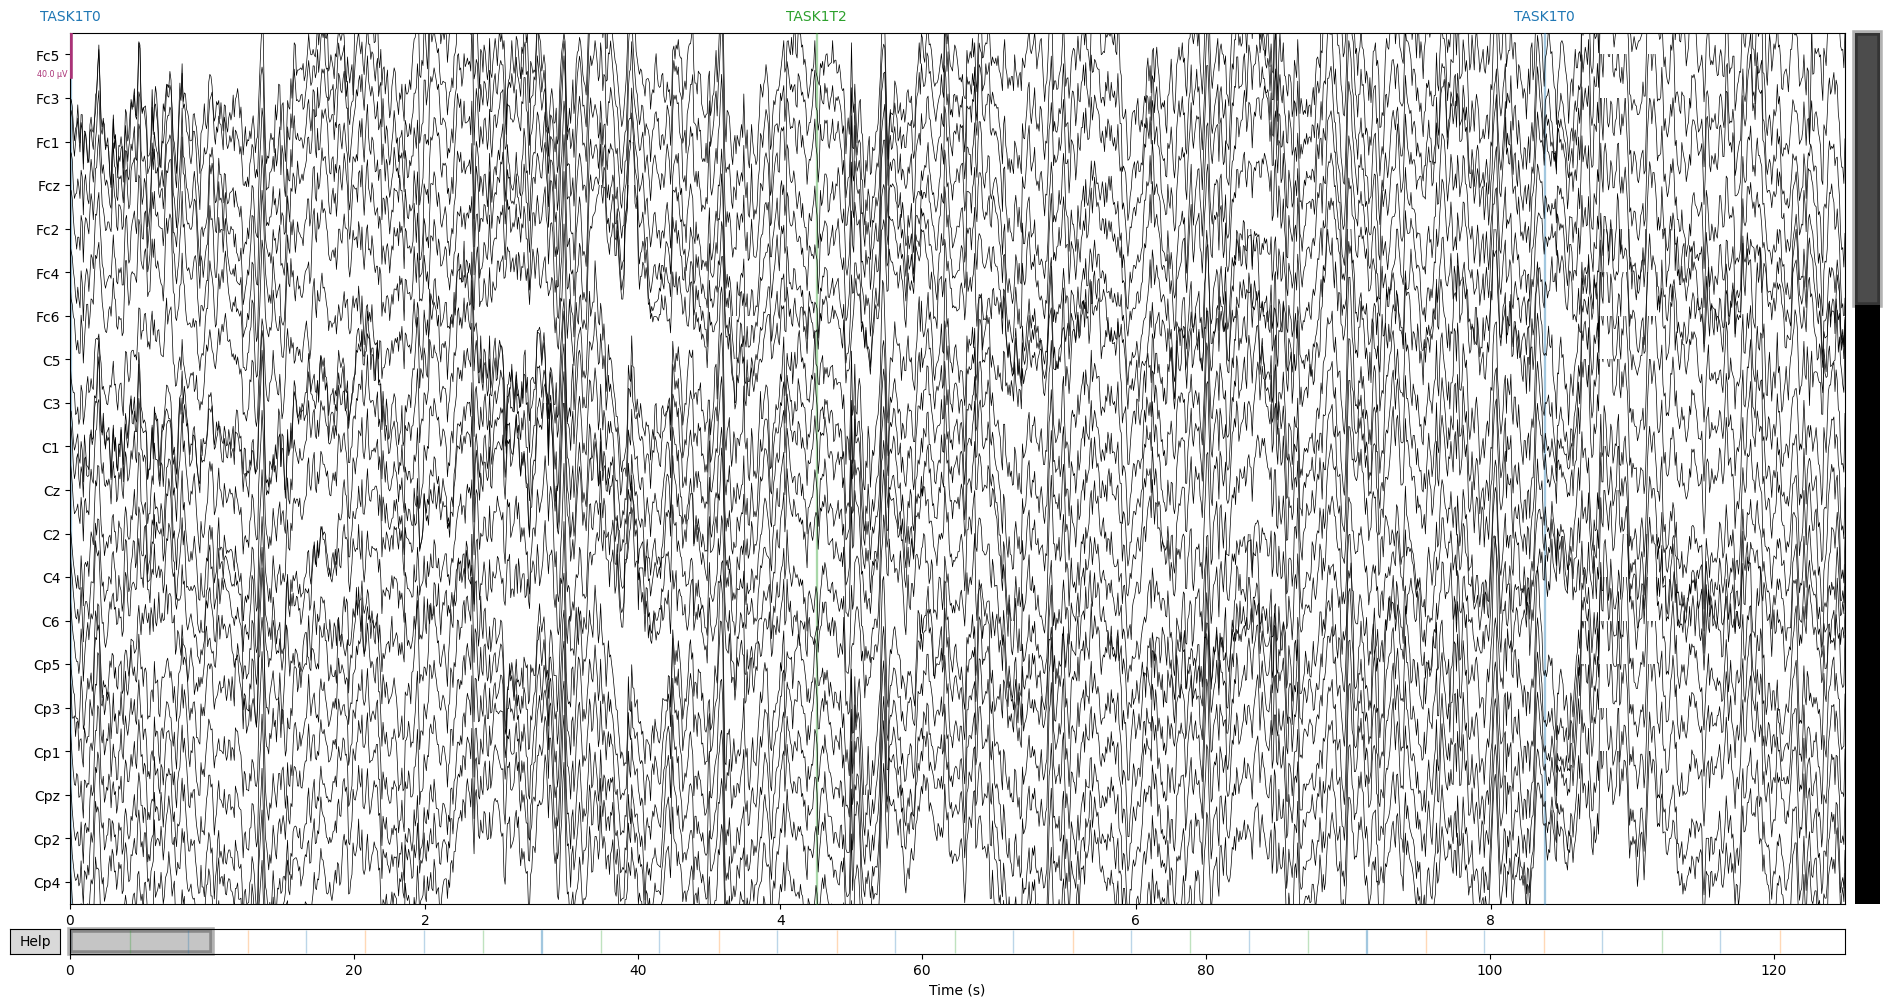

In [30]:
%matplotlib qt
raw.plot()

In [31]:
rn = raw.ch_names
print(rn)

['Fc5', 'Fc3', 'Fc1', 'Fcz', 'Fc2', 'Fc4', 'Fc6', 'C5', 'C3', 'C1', 'Cz', 'C2', 'C4', 'C6', 'Cp5', 'Cp3', 'Cp1', 'Cpz', 'Cp2', 'Cp4', 'Cp6', 'Fp1', 'Fpz', 'Fp2', 'Af7', 'Af3', 'Afz', 'Af4', 'Af8', 'F7', 'F5', 'F3', 'F1', 'Fz', 'F2', 'F4', 'F6', 'F8', 'Ft7', 'Ft8', 'T7', 'T8', 'T9', 'T10', 'Tp7', 'Tp8', 'P7', 'P5', 'P3', 'P1', 'Pz', 'P2', 'P4', 'P6', 'P8', 'Po7', 'Po3', 'Poz', 'Po4', 'Po8', 'O1', 'Oz', 'O2', 'Iz']


In [32]:
canales_eeg = ['C3', 'C4', 'Cz']


In [33]:
data, times = raw.get_data(return_times=True)
print(data.shape)
print(times.shape)

(64, 20000)
(20000,)


In [34]:
plt.plot(times, data[0])
plt.xlabel('Tiempo (s)')    
plt.ylabel('Amplitud (µV)')
plt.title('Señal EEG del canal Fp1')
plt.show()

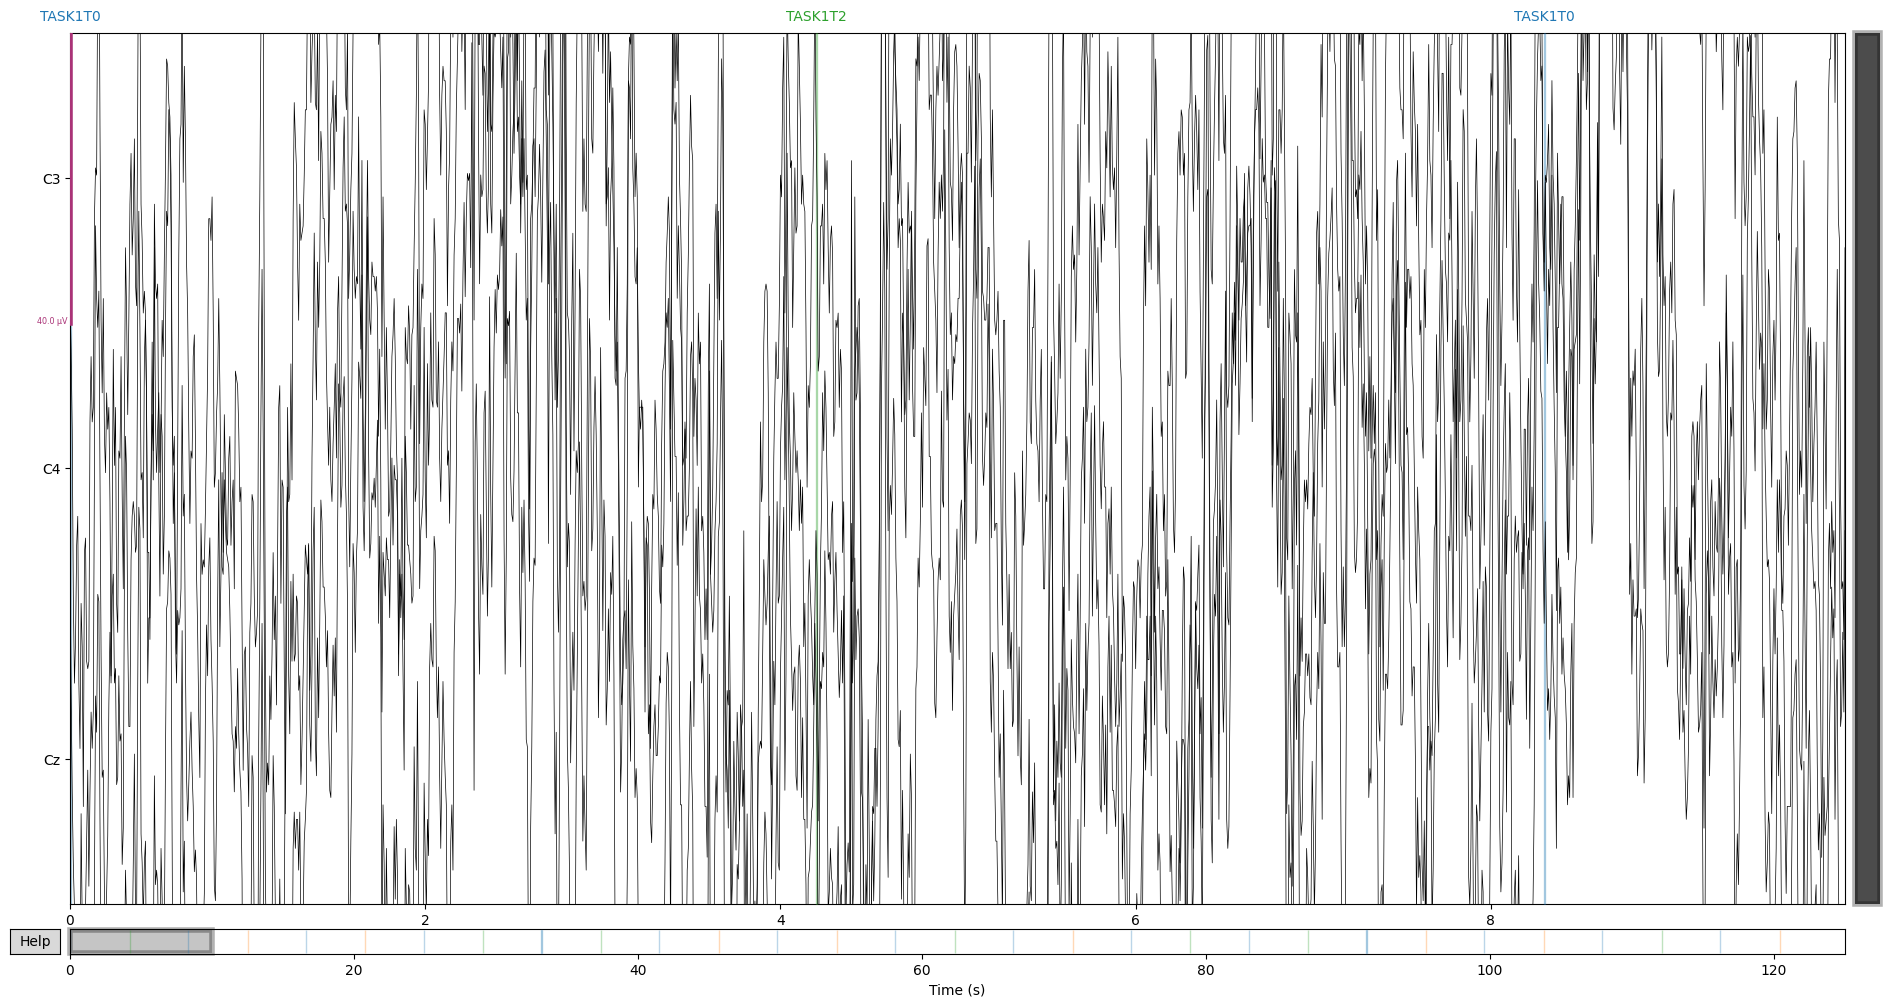

In [35]:
raw_sel = raw.copy().pick(canales_eeg)
raw_sel.plot()

In [36]:
data, times = raw_sel.get_data(return_times=True)
print(data.shape)

(3, 20000)


In [37]:
plt.figure(figsize=(10, 6))
for i in canales_eeg:
    plt.subplot(len(canales_eeg), 1, canales_eeg.index(i) + 1)
    plt.plot(times, data[canales_eeg.index(i)])
    plt.xlabel('Tiempo (s)')
    plt.ylabel('Amplitud (µV)') 
    plt.title(f'Señal EEG del canal {i}')
    plt.tight_layout()
plt.show()


# PRÁCTICA 3_PARTE 2 Análisis de Señales de EEG para entender la imaginación motora

**Laboratorio de bioseñales**

* Luisa Fernanda Llamas Baldovino
* Camila Andrea Montiel Zapata

In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mne
import glob
import os

#### **1. Cálculo de RMS y construcción de base de datos poblacional**

In [42]:


# 1. Definir los canales solicitados
raw_P2 = mne.io.read_raw_eeglab(r"sub-001_task-motion_run-3_eeg (1).set", preload=True)
canales_eeg_P2 = raw_P2.ch_names

# 2. Función para calcular el RMS por época y promediar
def calcular_rms_epocas(datos_clase):
    """
    Recibe un array numpy con la forma: (n_epocas, n_canales, n_tiempos)
    Retorna un array 1D con el RMS promedio por canal.
    """
    # 2.1 Calcular RMS a lo largo del eje del tiempo (eje 2)
    # np.mean(datos**2) calcula la media de los cuadrados, np.sqrt saca la raíz
    rms_por_epoca = np.sqrt(np.mean(datos_clase**2, axis=2))
    
    # 2.2 Promediar esos valores a través de todas las épocas (eje 0)
    rms_promedio = np.mean(rms_por_epoca, axis=0)
    
    return rms_promedio


# 3. Preparar la lectura de los 10 archivos
# Asegúrate de cambiar esta ruta por la carpeta real donde están tus 10 archivos .set
ruta_archivos = "C:/Users/HP/Desktop/UDEA/2026_1/LAB_BIOSEÑALES/EEG_IM_P3.2/*.set" 
archivos = glob.glob(ruta_archivos)

# Si tienes más de 10 en la carpeta, limitamos a 10 para el ejercicio
archivos = archivos[:10] 

resultados_poblacionales = []

# 4. Iterar sobre cada sujeto (archivo)
for i, archivo in enumerate(archivos):
    sujeto_id = f"Sujeto_{i+1}"
    print(f"\n--- Procesando {sujeto_id}: {os.path.basename(archivo)} ---")
    
    # Usando su código base: cargar señal continua
    raw = mne.io.read_raw_eeglab(archivo, preload=True)
    
    # Seleccionar solo los canales de interés
    raw_sel = raw.copy().pick(canales_eeg_P2)
    
    # ---> PASO CLAVE: Convertir la señal continua en épocas <---
    # Extraemos las anotaciones de eventos del archivo .set
    eventos, event_dict = mne.events_from_annotations(raw_sel)
    print(f"Eventos encontrados en este sujeto: {event_dict}")
    
    # ¡ATENCIÓN! Aquí debes ajustar el nombre de los triggers a como salgan en el 'event_dict'
    # En muchos datasets de Motor Imagery son 'T1' y 'T2', o '1' y '2'
    trigger_izq = 'TASK2T1' # <-- CAMBIAR POR EL REAL
    trigger_der = 'TASK2T2'   # <-- CAMBIAR POR EL REAL
    
    try:
        id_izq = event_dict[trigger_izq]
        id_der = event_dict[trigger_der]
        
        # Crear épocas desde t=0s hasta t=2s (ajusta los tiempos según tu experimento)
        epochs = mne.Epochs(raw_sel, eventos, event_id={'Izquierda': id_izq, 'Derecha': id_der}, 
                            tmin=0.0, tmax=2.0, baseline=None, preload=True, verbose=False)
        
        # Extraer datos como numpy arrays (n_epocas, n_canales, n_tiempos) y calcular RMS
        datos_izq = epochs['Izquierda'].get_data()
        rms_izq = calcular_rms_epocas(datos_izq)
        
        datos_der = epochs['Derecha'].get_data()
        rms_der = calcular_rms_epocas(datos_der)
        
        # Construir fila para Mano Izquierda
        fila_izq = {'Sujeto': sujeto_id, 'Grupo': 'Mano Izquierda'}
        for idx, canal in enumerate(canales_eeg_P2):
            fila_izq[canal] = rms_izq[idx]
        resultados_poblacionales.append(fila_izq)
        
        # Construir fila para Mano Derecha
        fila_der = {'Sujeto': sujeto_id, 'Grupo': 'Mano Derecha'}
        for idx, canal in enumerate(canales_eeg_P2):
            fila_der[canal] = rms_der[idx]
        resultados_poblacionales.append(fila_der)
        
    except KeyError as e:
        print(f"Advertencia: No se encontró el trigger {e} en el archivo {archivo}.")


# 5. Construcción del DataFrame final
df_final = pd.DataFrame(resultados_poblacionales)

#Opcional: Reordenar las columnas para asegurar que Sujeto y Grupo queden de primeras
columnas = ['Sujeto', 'Grupo'] + canales_eeg_P2
df_final = df_final[columnas]

print("\n--- Base de Datos Poblacional ---")
display(df_final)

# Guardar en un CSV si lo necesitan para un análisis posterior (Machine learning, estadística, etc.)
#df_final.to_csv("base_datos_rms.csv", index=False)


--- Procesando Sujeto_1: sub-001_task-motion_run-8_eeg.set ---
Used Annotations descriptions: [np.str_('TASK2T0'), np.str_('TASK2T1'), np.str_('TASK2T2')]
Eventos encontrados en este sujeto: {np.str_('TASK2T0'): 1, np.str_('TASK2T1'): 2, np.str_('TASK2T2'): 3}

--- Procesando Sujeto_2: sub-008_task-motion_run-8_eeg.set ---
Used Annotations descriptions: [np.str_('TASK2T0'), np.str_('TASK2T1'), np.str_('TASK2T2')]
Eventos encontrados en este sujeto: {np.str_('TASK2T0'): 1, np.str_('TASK2T1'): 2, np.str_('TASK2T2'): 3}

--- Procesando Sujeto_3: sub-010_task-motion_run-4_eeg.set ---
Used Annotations descriptions: [np.str_('TASK2T0'), np.str_('TASK2T1'), np.str_('TASK2T2')]
Eventos encontrados en este sujeto: {np.str_('TASK2T0'): 1, np.str_('TASK2T1'): 2, np.str_('TASK2T2'): 3}

--- Procesando Sujeto_4: sub-012_task-motion_run-12_eeg.set ---
Used Annotations descriptions: [np.str_('TASK2T0'), np.str_('TASK2T1'), np.str_('TASK2T2')]
Eventos encontrados en este sujeto: {np.str_('TASK2T0'): 

,Sujeto,Grupo,Fc5,Fc3,Fc1,Fcz,Fc2,Fc4,Fc6,C5,...,P8,Po7,Po3,Poz,Po4,Po8,O1,Oz,O2,Iz
0,Sujeto_1,Mano Izquierda,0.000046,0.000045,0.000045,0.000047,0.000043,0.000039,0.000039,0.000045,...,0.000038,0.000049,0.000049,0.000053,0.000049,0.000047,0.000051,0.000050,0.000054,0.000049
1,Sujeto_1,Mano Derecha,0.000053,0.000052,0.000055,0.000059,0.000051,0.000044,0.000042,0.000052,...,0.000037,0.000052,0.000055,0.000056,0.000049,0.000048,0.000054,0.000052,0.000050,0.000050
2,Sujeto_2,Mano Izquierda,0.000036,0.000038,0.000032,0.000029,0.000030,0.000030,0.000034,0.000027,...,0.000026,0.000033,0.000031,0.000028,0.000033,0.000029,0.000030,0.000029,0.000028,0.000031
3,Sujeto_2,Mano Derecha,0.000046,0.000043,0.000039,0.000037,0.000038,0.000038,0.000032,0.000029,...,0.000029,0.000034,0.000032,0.000033,0.000035,0.000031,0.000032,0.000031,0.000032,0.000031
4,Sujeto_3,Mano Izquierda,0.000105,0.000064,0.000077,0.000093,0.000059,0.000053,0.000111,0.000063,...,0.000104,0.000079,0.000108,0.000061,0.000044,0.000108,0.000080,0.000063,0.000071,0.000055
5,Sujeto_3,Mano Derecha,0.000136,0.000072,0.000084,0.000111,0.000064,0.000066,0.000139,0.000093,...,0.000131,0.000120,0.000133,0.000086,0.000043,0.000129,0.000100,0.000078,0.000106,0.000091
6,Sujeto_4,Mano Izquierda,0.000053,0.000050,0.000049,0.000048,0.000045,0.000044,0.000041,0.000037,...,0.000027,0.000031,0.000030,0.000030,0.000026,0.000026,0.000029,0.000029,0.000028,0.000025
7,Sujeto_4,Mano Derecha,0.000050,0.000050,0.000050,0.000050,0.000048,0.000047,0.000044,0.000037,...,0.000029,0.000029,0.000029,0.000030,0.000027,0.000027,0.000029,0.000027,0.000028,0.000023
8,Sujeto_5,Mano Izquierda,0.000031,0.000034,0.000033,0.000033,0.000031,0.000033,0.000030,0.000028,...,0.000023,0.000028,0.000027,0.000026,0.000023,0.000021,0.000026,0.000024,0.000023,0.000023
9,Sujeto_5,Mano Derecha,0.000031,0.000028,0.000027,0.000028,0.000029,0.000030,0.000023,0.000027,...,0.000019,0.000023,0.000028,0.000022,0.000022,0.000018,0.000023,0.000020,0.000019,0.000021
